In [263]:
from ase.io import read
from ase.build import molecule
from ase import Atoms
# from dscribe.descriptors import SOAP
import dscribe

import pickle
import os
import struct
# from scipy import sparse

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt

from e3nn.o3 import Irrep, Irreps, wigner_3j, matrix_to_angles, Linear, FullyConnectedTensorProduct, TensorProduct, SphericalHarmonics
from e3nn.nn import Extract

In [264]:
# test_info = torch.load('old_models/model_HfO2_18_subgraph_validate_patience_reduced_16_test_info.pt')

# test_info = torch.load('old_models/model_HfO2_1_subgraph_validate_patience_test_info.pt')
# test_info = torch.load('model_HfO2_18_subgraph_validate_patience_reduced_attention_structure_3_test_info.pt')
# test_info = torch.load('model_HfO2_18_subgraph_validate_latest_thickness_3_novirtual_test_info.pt')
# test_info = torch.load('model_HfO2_18_subgraph_validate_latest_thickness_6_2MP_test_info.pt')
test_info = torch.load('model_HfO2_18_subgraph_validate_latest_thickness_3_2MP_test_info.pt')
# test_info = torch.load('model_HfO2_1_subgraph_validate_rcut5_reduced_test_info.pt')
# test_info = torch.load('model_HfO2_18_subgraph_validate_patience_reduced_32_structure_1_test_info.pt')

# test_info = torch.load('model_HfO2_18_subgraph_validate_latest_thickness_12_test_info.pt')

In [265]:
node_pred = test_info['node_pred']
node_label = test_info['node_label']

flattened_node_pred = test_info['flattened_node_pred']
flattened_node_label = test_info['flattened_node_labels']

In [266]:
error = abs(node_pred - node_label)
print(torch.mean(error)*1000)

print(torch.std(error)*1000)
# error = abs(flattened_node_pred - flattened_node_label)
# print(torch.mean(error))

tensor(8.6045, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(21.0073, dtype=torch.float64, grad_fn=<MulBackward0>)


In [267]:
edge_pred = test_info['edge_pred']
edge_label = test_info['edge_label']

flattened_edge_pred = test_info['flattened_edge_pred']
flattened_edge_label = test_info['flattened_edge_labels']

error = abs(edge_pred - edge_label)
print(torch.mean(error)*1000)

print(torch.std(error)*1000)
# error = abs(flattened_edge_pred - flattened_edge_label)
# print(torch.mean(error))

tensor(0.2420, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(0.4257, dtype=torch.float64, grad_fn=<MulBackward0>)


Text(0, 0.5, 'predicted energies for each Hamiltonian block (Hartree)')

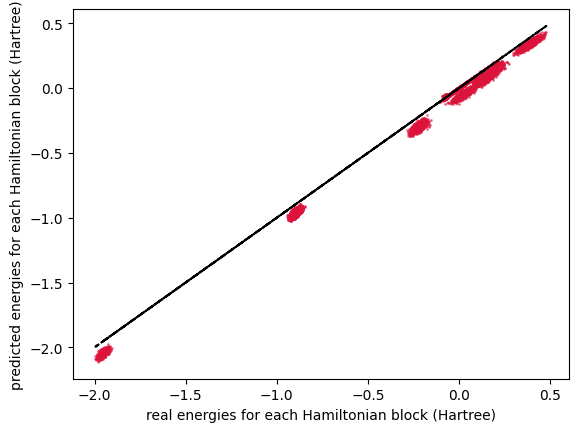

In [268]:

node_pred_values = np.concatenate([batch_edge.detach().cpu().numpy().flatten() for batch_edge in node_pred])
node_label_values = np.concatenate([batch_edge.detach().cpu().numpy().flatten() for batch_edge in node_label])

plt.scatter(node_label_values, node_pred_values, s=1, alpha=0.5, color = 'crimson')
plt.plot(node_label_values, node_label_values, c='k',linestyle='dashed')

plt.xlabel("real energies for each Hamiltonian block (Hartree)")
plt.ylabel("predicted energies for each Hamiltonian block (Hartree)")




In [269]:
asdf

NameError: name 'asdf' is not defined

In [ ]:


edge_pred_values = np.concatenate([batch_edge.detach().cpu().numpy().flatten() for batch_edge in edge_pred])
edge_label_values = np.concatenate([batch_edge.detach().cpu().numpy().flatten() for batch_edge in edge_label])

plt.scatter(edge_label_values, edge_pred_values, s=1, alpha=0.5, color = 'crimson')
plt.plot(edge_label_values, edge_label_values, c='k',linestyle='dashed')

plt.xlabel("real average energies for each Hamiltonian block")
plt.ylabel("predicted average energies for each Hamiltonian block")

plt.xlim(-2, 0.5)
plt.ylim(-2, 0.5)

KeyboardInterrupt: 

0.005390060249442814


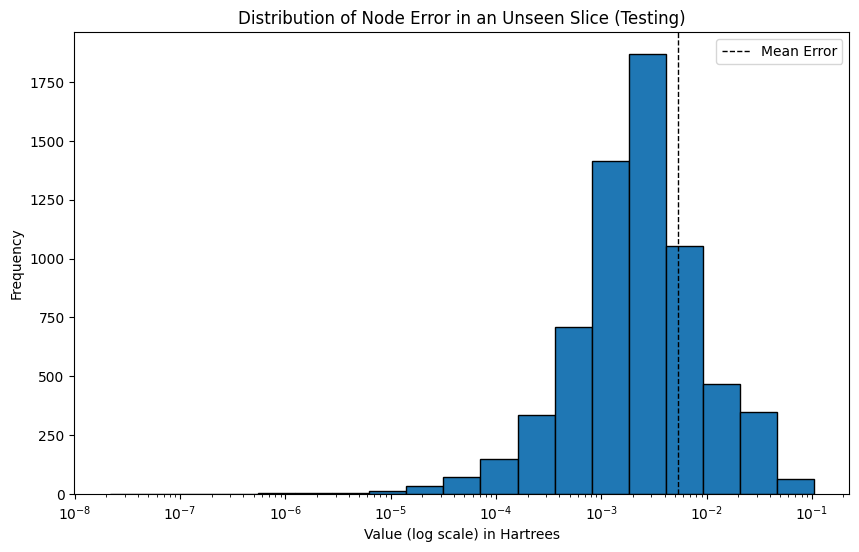

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
# data = np.random.lognormal(mean=0, sigma=2, size=1000)
data = abs(node_pred_values-node_label_values)

data = data[data > 0]

# Determine the range of the data
data_min = np.min(data)
data_max = np.max(data)

# Create bins that are logarithmically spaced
bins = np.logspace(np.log10(data_min), np.log10(data_max), num=20)  # 20 bins

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=bins, edgecolor='black')

# Set logarithmic scale on the x-axis
plt.xscale('log')

# Add titles and labels
plt.title('Distribution of Node Error in an Unseen Slice (Testing)')
plt.xlabel('Value (log scale) in Hartrees')
plt.ylabel('Frequency')


#plot vertical line at the mean of the data
plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1, label='Mean Error')

node_error = data.mean()
# plt.axvline(MAELoss.detach().cpu(), color='r', linestyle='dashed', linewidth=1, label='MAE Loss')

# plt.axvline(loss_edge2.detach().cpu(), color='r', linestyle='dashed', linewidth=1, label='Edge Loss')

# plt.axvline(loss_node2.detach().cpu(), color='b', linestyle='dashed', linewidth=1, label='Node Loss')

plt.legend()


print(data.mean())

0.0004400414414200764


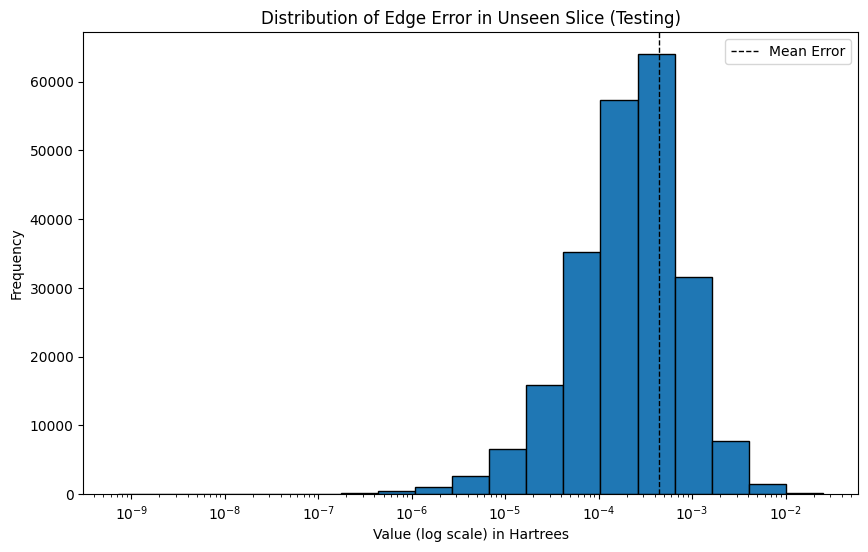

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
# data = np.random.lognormal(mean=0, sigma=2, size=1000)
data = abs(edge_pred_values-edge_label_values)

data = data[data > 0]

# Determine the range of the data
data_min = np.min(data)
data_max = np.max(data)

# Create bins that are logarithmically spaced
bins = np.logspace(np.log10(data_min), np.log10(data_max), num=20)  # 20 bins

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=bins, edgecolor='black')

# Set logarithmic scale on the x-axis
plt.xscale('log')

# Add titles and labels
plt.title('Distribution of Edge Error in Unseen Slice (Testing)')
plt.xlabel('Value (log scale) in Hartrees')
plt.ylabel('Frequency')


#plot vertical line at the mean of the data
plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1, label='Mean Error')

plt.legend()

edge_error = data.mean()


print(data.mean())

0.06982841785124702


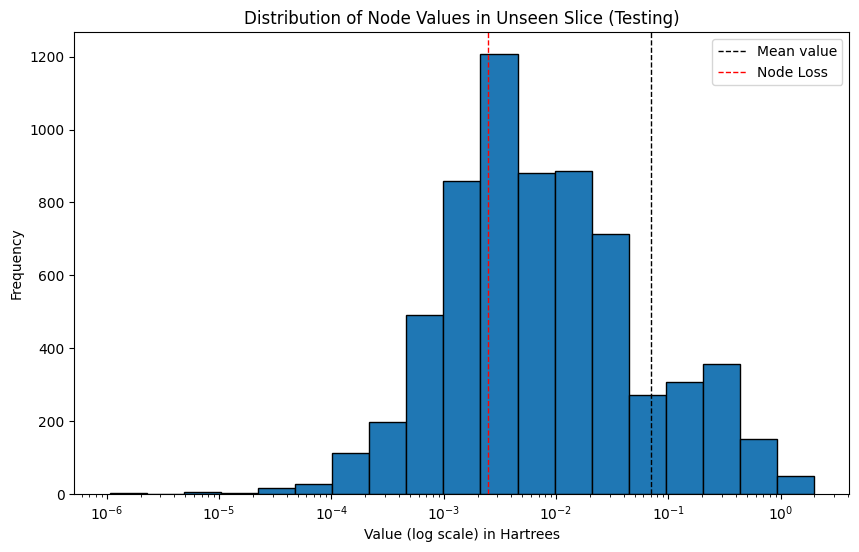

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
# data = np.random.lognormal(mean=0, sigma=2, size=1000)
data = abs(node_label_values)

data = data[data > 0]

# Determine the range of the data
data_min = np.min(data)
data_max = np.max(data)

# Create bins that are logarithmically spaced
bins = np.logspace(np.log10(data_min), np.log10(data_max), num=20)  # 20 bins

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=bins, edgecolor='black')

# Set logarithmic scale on the x-axis
plt.xscale('log')

# Add titles and labels
plt.title('Distribution of Node Values in Unseen Slice (Testing)')
plt.xlabel('Value (log scale) in Hartrees')
plt.ylabel('Frequency')


#plot vertical line at the mean of the data
plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1, label='Mean value')


# plt.axvline(MAELoss.detach().cpu(), color='r', linestyle='dashed', linewidth=1, label='MAE Loss')

# plt.axvline(loss_edge2.detach().cpu(), color='r', linestyle='dashed', linewidth=1, label='Edge Loss')

plt.axvline(0.0025, color='r', linestyle='dashed', linewidth=1, label='Node Loss')


plt.legend()


print(data.mean())

0.00375817290962267


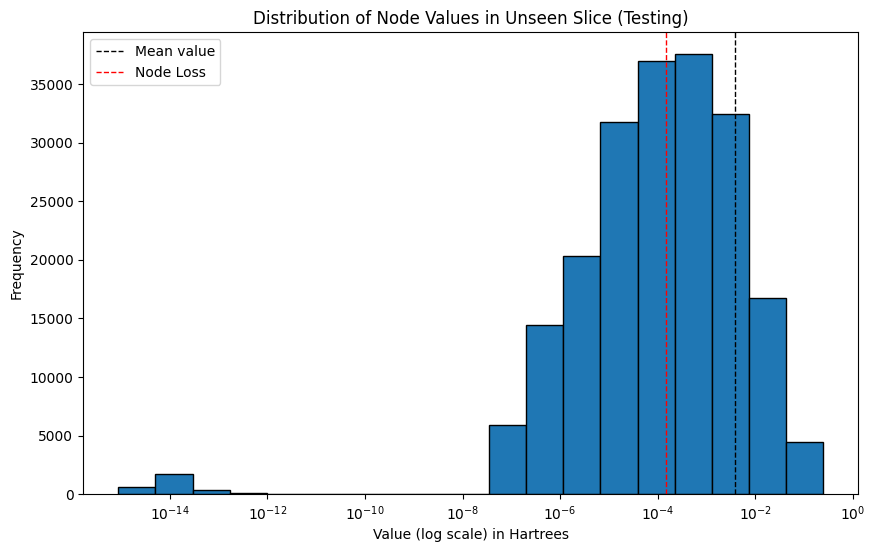

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
# data = np.random.lognormal(mean=0, sigma=2, size=1000)
data = abs(edge_label_values)

data = data[data > 0]

# Determine the range of the data
data_min = np.min(data)
data_max = np.max(data)

# Create bins that are logarithmically spaced
bins = np.logspace(np.log10(data_min), np.log10(data_max), num=20)  # 20 bins

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=bins, edgecolor='black')

# Set logarithmic scale on the x-axis
plt.xscale('log')

# Add titles and labels
plt.title('Distribution of Node Values in Unseen Slice (Testing)')
plt.xlabel('Value (log scale) in Hartrees')
plt.ylabel('Frequency')


#plot vertical line at the mean of the data
plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1, label='Mean value')


# plt.axvline(MAELoss.detach().cpu(), color='r', linestyle='dashed', linewidth=1, label='MAE Loss')

# plt.axvline(loss_edge2.detach().cpu(), color='r', linestyle='dashed', linewidth=1, label='Edge Loss')

plt.axvline(0.00014897141078396624, color='r', linestyle='dashed', linewidth=1, label='Node Loss')

plt.legend()


print(data.mean())

In [ ]:
print(node_training_labels[2])
print(node_training[2])

tensor([-0.2314,  0.0343,  0.0551, -0.0247,  0.0343,  0.0551, -0.0247,  0.1618,
        -0.0254, -0.0095, -0.0254,  0.1534,  0.0124, -0.0095,  0.0124,  0.1354,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.00

In [ ]:
print(training_labels[100])
print(training[100])

tensor([-2.4658e-06,  0.0000e+00,  1.1898e-05,  6.4128e-06,  0.0000e+00,
        -1.1712e-05, -5.8796e-06, -3.8633e-06,  5.4769e-07,  1.8389e-07,
        -2.8422e-14,  5.0540e-05,  2.9835e-05, -7.1054e-15,  2.7555e-05,
         1.1666e-05,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0

In [ ]:
no_parity = True

def irreps_from_l1l2(l1, l2, mul, no_parity=no_parity):
    r'''
    non-spinful example: l1=1, l2=2 (1x2) ->
    required_irreps_full=1+2+3, required_irreps=1+2+3, required_irreps_x1=None
    
    spinful example: l1=1, l2=2 (1x0.5)x(2x0.5) ->
    required_irreps_full = 1+2+3 + 0+1+2 + 1+2+3 + 2+3+4
    required_irreps = (1+2+3)x0 = 1+2+3
    required_irreps_x1 = (1+2+3)x1 = [0+1+2, 1+2+3, 2+3+4]
    
    notice that required_irreps_x1 is a list of Irreps
    '''
    p = 1
    if not no_parity:
        p = (-1) ** (l1 + l2)
    required_ls = range(abs(l1 - l2), l1 + l2 + 1)
    required_irreps = Irreps([(mul, (l, p)) for l in required_ls])

    return required_irreps


def orbital_analysis(atom_orbitals, required_block_type, targets=None, no_parity=no_parity): #note that atom_orbitals represent the unique elements in the structure, not the actual number of atoms 
    r'''
    example of atom_orbitals: {'42': [0, 0, 0, 1, 1, 2, 2], '16': [0, 0, 1, 1, 2]} 
    
    required_block_type: 's' - specify; 'a' - all; 'o' - off-diagonal; 'd' - diagonal; 
    '''

    assert required_block_type in ['s', 'a', 'o', 'd']
    if required_block_type == 's':
        net_out_irreps = Irreps(None)
        for target in targets:
            l1, l2 = None, None
            for N_M_str, block_indices in target.items():
                atom1, atom2 = N_M_str.split()
                if l1 is None and l2 is None:
                    l1 = atom_orbitals[atom1][block_indices[0]]
                    l2 = atom_orbitals[atom2][block_indices[1]]
                    net_out_irreps += irreps_from_l1l2(l1, l2, 1, no_parity=no_parity)[0]
                else:
                    assert l1 == atom_orbitals[atom1][block_indices[0]] and l2 == atom_orbitals[atom2][block_indices[1]], f'Hamiltonian block angular quantum numbers not all the same in target {target}'
                    
    else:
        hoppings_list = [] # [{'42 16': [4, 3]}, ...]
        for atom1, orbitals1 in atom_orbitals.items():
            for atom2, orbitals2 in atom_orbitals.items():
                hopping_key = atom1 + ' ' + atom2
                # if element_pairs:
                #     if hopping_key not in element_pairs:
                #         continue
                for orbital1 in range(len(orbitals1)):
                    for orbital2 in range(len(orbitals2)):
                        hopping_orbital = [orbital1, orbital2]
                        hoppings_list.append({hopping_key: hopping_orbital}) #keys of hopping_list contain the atomic numbers of the two atoms, values contain the orbital indices of the two interacting orbitals 
        
        il_list = [] # [[1, 1, 2, 0], ...] this means the hopping is from 1st l=1 orbital to 0th l=2 orbital.
        for hopping in hoppings_list:
            for N_M_str, block in hopping.items():
                atom1, atom2 = N_M_str.split()
                l1 = atom_orbitals[atom1][block[0]] #finds the l of each orbital pair dictionary in the list, block contains the pair of orbital indices, which are mapped to ls by atomic_orbitals
                l2 = atom_orbitals[atom2][block[1]]
                il1 = block[0] - atom_orbitals[atom1].index(l1) #il1 specifies the index of orbitals with the same l e.g. if orbital index is 3, but it is the 2nd l=1 orbital, it is 3-1 = 2, with 1 being the index of the first l=1 orbital
                il2 = block[1] - atom_orbitals[atom2].index(l2)
            il_list.append([l1, il1, l2, il2])

        hoppings_list_mask = [False for _ in range(len(hoppings_list))] # if that hopping is already included, then it is True
        targets = []
        net_out_irreps_list = []
        net_out_irreps = Irreps(None)

        # print(hoppings_list)
        for hopping1_index in range(len(hoppings_list)):
            target = {}
            if not hoppings_list_mask[hopping1_index]: #make sure that there is no repeat in entries
            #     is_diagonal = il_list[hopping1_index][0: 2] == il_list[hopping1_index][2: 4]
                hoppings_list_mask[hopping1_index] = True
            #     if is_diagonal and required_block_type == 'o':
            #         continue
            #     if not is_diagonal and required_block_type == 'd':
            #         continue
                target.update(hoppings_list[hopping1_index]) #add the key (atomic species of the interacting atoms) and its values (orbital indices of the interacting orbitals) to the target dictionary. 
                for hopping2_index in range(len(hoppings_list)):
                    if not hoppings_list_mask[hopping2_index]:
                        if il_list[hopping1_index] == il_list[hopping2_index]: # il1 = il2 means the two hoppings are similar (similar means that they have the same l1 and l2 and the same orbital indices among orbitals of the same l1 and l2 )
                            target.update(hoppings_list[hopping2_index]) #if the two are similar, the target dictionary should now contain an additional entry (atomic numbers + orbital indices of interacting orbitals).
                            hoppings_list_mask[hopping2_index] = True
                targets.append(target) #each target in targets represent a specific group of similar orbital interactions, between the nth l1 orbital of atom 1 and the mth l2 orbital of atom 2

                # print(il_list)

                
                # print(hoppings_list[0].values())
                l1, l2 = il_list[hopping1_index][0], il_list[hopping1_index][2]
                # orbital_pair = list(hoppings_list[hopping1_index])
                # print(orbital_pair)
                irreps_new = irreps_from_l1l2(l1, l2, 1, no_parity=no_parity)
                # net_out_irreps_list.append(irreps_new)
                # print(net_out_irreps_list)

                net_out_irreps = net_out_irreps+irreps_new
    
    return targets, net_out_irreps, net_out_irreps.sort()[0].simplify()

In [ ]:
def element_statistics(numbers):
    # TODO 没有处理数据集包括不同元素组成的情况
    index_to_Z, inverse_indices = torch.unique(numbers, sorted=True, return_inverse=True)
    Z_to_index = torch.full((100,), -1, dtype=torch.int64)
    Z_to_index[index_to_Z] = torch.arange(len(index_to_Z))

    # for data in data_list:
    #     data.x = Z_to_index[data.x]

    return index_to_Z, Z_to_index


def process_targets(orbital_types, index_to_Z, targets): 
    Z_to_index = torch.full((100,), -1, dtype=torch.int64)
    Z_to_index[index_to_Z] = torch.arange(len(index_to_Z))
    
    orbital_types = list(map(lambda x: np.array(x, dtype=np.int32), orbital_types))
    orbital_types_cumsum = list(map(lambda x: np.concatenate([np.zeros(1, dtype=np.int32), 
                                                                np.cumsum(2 * x + 1)]), orbital_types))

    # = process the orbital indices into block slices =
    equivariant_blocks, out_js_list = [], []
    out_slices = [0]
    for target in targets:
        out_js = None
        equivariant_block = dict()
        for N_M_str, block_indices in target.items():
            i, j = map(lambda x: Z_to_index[int(x)], N_M_str.split())
            block_slice = [
                orbital_types_cumsum[i][block_indices[0]], #defines the indices that indicate the start and end of the matrix block in row and column direction 
                orbital_types_cumsum[i][block_indices[0] + 1],
                orbital_types_cumsum[j][block_indices[1]],
                orbital_types_cumsum[j][block_indices[1] + 1]
            ]
            equivariant_block.update({N_M_str: block_slice})
            if out_js is None:
                out_js = (orbital_types[i][block_indices[0]], orbital_types[j][block_indices[1]])
            else:
                assert out_js == (orbital_types[i][block_indices[0]], orbital_types[j][block_indices[1]])
        equivariant_blocks.append(equivariant_block)
        out_js_list.append(tuple(map(int, out_js)))
        out_slices.append(out_slices[-1] + (2 * out_js[0] + 1) * (2 * out_js[1] + 1))
    
    return equivariant_blocks, out_js_list, out_slices

In [ ]:
# atom_orbitals = {'1': [0, 0, 1],'8':[0,0,1,1,2]}

atom_orbitals = {'8':[0,1],'72':[0,0,1,2]} #SZVP 

# atom_orbitals = {'1': [0,0,1]}
numbers = test_batch.x[0:test_batch.labelled_node_size]

required_block_type = 'a'

targets, net_out_irreps, net_out_irreps_simplified =  orbital_analysis(atom_orbitals, required_block_type, targets=None, no_parity=no_parity)
print(net_out_irreps)
print(net_out_irreps_simplified)
print(targets)

# atom_orbitals = {'1': [0, 0, 1]}
# orbital_types = [[0,0,1]] #orbital types of each atom in the structure 
# orbital_types = [[0,0,1],[0,0,1,1,2]] #orbital types of each atom in the structure 


orbital_types = [[0,1],[0,0,1,2]]
# orbital_types = [[0,0,1,2],[0,1]]
required_block_type = 'a'

targets, net_out_irreps, net_out_irreps_simplified =  orbital_analysis(atom_orbitals, required_block_type, targets=None, no_parity=no_parity)

index_to_Z, Z_to_index  = element_statistics(numbers)

print(index_to_Z)
# print(Z_to_index)

equivariant_blocks, out_js_list, out_slices = process_targets(orbital_types, index_to_Z, targets)


print(equivariant_blocks)#start and end indices of the equivariant blocks in i and j direction for each target in targets
print(out_js_list) #all the l1 l2 interactions needed 
print(out_slices) #marks the start and end of indices belonging to a certain target. Slice 1 (0 to 1) corresponds to the first target in equivariant blocks 
print(len(out_slices))

1x0e+1x1e+1x1e+1x0e+1x1e+1x2e+1x0e+1x2e+1x1e+1x1e+1x2e+1x3e+1x0e+1x1e+1x2e+1x1e+1x2e+1x3e+1x0e+1x2e+1x2e+1x0e+1x1e+1x2e+1x3e+1x4e
6x0e+8x1e+8x2e+3x3e+1x4e
[{'8 8': [0, 0], '8 72': [0, 0], '72 8': [0, 0], '72 72': [0, 0]}, {'8 8': [0, 1], '8 72': [0, 2], '72 8': [0, 1], '72 72': [0, 2]}, {'8 8': [1, 0], '8 72': [1, 0], '72 8': [2, 0], '72 72': [2, 0]}, {'8 8': [1, 1], '8 72': [1, 2], '72 8': [2, 1], '72 72': [2, 2]}, {'8 72': [0, 1], '72 72': [0, 1]}, {'8 72': [0, 3], '72 72': [0, 3]}, {'8 72': [1, 1], '72 72': [2, 1]}, {'8 72': [1, 3], '72 72': [2, 3]}, {'72 8': [1, 0], '72 72': [1, 0]}, {'72 8': [1, 1], '72 72': [1, 2]}, {'72 8': [3, 0], '72 72': [3, 0]}, {'72 8': [3, 1], '72 72': [3, 2]}, {'72 72': [1, 1]}, {'72 72': [1, 3]}, {'72 72': [3, 1]}, {'72 72': [3, 3]}]
tensor([ 8, 72])
[{'8 8': [0, 1, 0, 1], '8 72': [0, 1, 0, 1], '72 8': [0, 1, 0, 1], '72 72': [0, 1, 0, 1]}, {'8 8': [0, 1, 1, 4], '8 72': [0, 1, 2, 5], '72 8': [0, 1, 1, 4], '72 72': [0, 1, 2, 5]}, {'8 8': [1, 4, 0, 1], '8 7

In [ ]:


def unflatten(H_pred, numbers, edge_index, equivariant_blocks, atom_orbitals, out_slices):  

    H_prev = {}

    for index_edge in range(edge_index.shape[1]):


        i = edge_index[0][index_edge].item() #atom index 
        j = edge_index[1][index_edge].item()

        key_term = (i,j)#edge key term 

        num_orbitals_i = np.sum(2*np.array(atom_orbitals[str(numbers[i].item())])+1)
        num_orbitals_j = np.sum(2*np.array(atom_orbitals[str(numbers[j].item())])+1)


        
        fill = 0 
        init = torch.full((num_orbitals_i, num_orbitals_j), fill, dtype=float)
        H_prev[key_term] = init

        for index_target, equivariant_block in enumerate(equivariant_blocks):
            for N_M_str, block_slice in equivariant_block.items():
                slice_row = slice(block_slice[0], block_slice[1])
                slice_col = slice(block_slice[2], block_slice[3])
                len_row = block_slice[1] - block_slice[0]
                len_col = block_slice[3] - block_slice[2]
                slice_out = slice(out_slices[index_target], out_slices[index_target + 1])

                # print(H_prev)
                # print(H_prev[key_term][slice_row, slice_col])
                # print(H_pred[index_edge][slice_out].reshape(len_row, len_col))

                condition_atomic_number_i, condition_atomic_number_j = N_M_str.split()

                if (numbers[edge_index[0][index_edge]].item() == int(condition_atomic_number_i) and numbers[edge_index[1][index_edge]].item() == int(condition_atomic_number_j)):
                    H_prev[key_term][slice_row, slice_col] = H_pred[index_edge][slice_out].reshape(len_row, len_col)

    return H_prev

In [ ]:
print(test_batch.edge_index[:,0:test_batch.labelled_edge_size])
print(test_batch.labelled_edge_size)
# print(test_batch)

# print(torch.arange(test_batch.labelled_node_size.item()))

onsite_edge_index = torch.cat((torch.arange(test_batch.labelled_node_size.item()).unsqueeze(0),torch.arange(test_batch.labelled_node_size.item()).unsqueeze(0)),0)
numbers = test_batch.x[0:test_batch.labelled_node_size]

print(onsite_edge_index.shape)
print(numbers)

tensor([[  0,   0,   0,  ..., 223, 223, 223],
        [ 45,  21, 190,  ..., 213, 215, 219]])
tensor([13336])
torch.Size([2, 224])
tensor([ 8,  8,  8, 72,  8,  8, 72,  8,  8,  8, 72,  8,  8, 72, 72,  8,  8, 72,
         8, 72,  8,  8, 72,  8, 72,  8, 72,  8,  8,  8,  8, 72, 72,  8,  8,  8,
         8,  8, 72, 72,  8, 72,  8,  8,  8,  8,  8, 72, 72,  8, 72, 72, 72,  8,
         8, 72, 72, 72, 72,  8,  8,  8,  8, 72,  8, 72,  8, 72,  8,  8,  8,  8,
         8, 72, 72,  8,  8, 72,  8,  8,  8,  8,  8,  8,  8,  8,  8, 72, 72, 72,
        72, 72,  8,  8,  8,  8, 72,  8,  8, 72,  8, 72,  8,  8,  8,  8,  8,  8,
         8,  8, 72, 72,  8,  8,  8, 72, 72,  8,  8,  8,  8, 72,  8,  8,  8, 72,
         8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8, 72, 72,  8,  8,
         8, 72,  8,  8,  8,  8, 72, 72, 72, 72,  8,  8,  8,  8, 72,  8, 72,  8,
         8, 72, 72, 72,  8,  8,  8,  8,  8, 72, 72,  8,  8, 72, 72,  8,  8,  8,
        72, 72, 72,  8, 72,  8, 72,  8,  8,  8,  8,  8,  8,  8,  8,  8

In [ ]:
# node_prediction = unflatten(node_training,test_batch.edge_index,equivariant_blocks,out_slices)
node_label = unflatten(node_training_labels,numbers, onsite_edge_index,equivariant_blocks,atom_orbitals,out_slices)
node_pred = unflatten(node_training,numbers, onsite_edge_index,equivariant_blocks,atom_orbitals,out_slices)


print(node_label[(3,3)])
print(node_pred[(3,3)])
# print(node_label[(2,2)])
# print(node_pred[(2,2)])
# print(node_training_labels[2])
# print(node_training[2])

#compute mean difference between predicted and actual Hamiltonian blocks
node_errors = []

for key in node_label.keys():
    node_error = torch.mean(abs(torch.abs(node_label[key]-node_pred[key])))
    node_errors.append(node_error.item())

print(np.mean(np.array(node_errors)))
print(np.max(np.array(node_errors)))
print(np.min(np.array(node_errors)))

tensor([[-1.9591e+00, -7.4543e-02, -9.8386e-04,  1.0091e-03,  2.6474e-03,
         -8.4095e-03, -1.4167e-03,  6.0383e-04,  1.1406e-03,  1.2877e-03],
        [-7.4543e-02,  2.4915e-02, -1.5921e-03, -1.7037e-03, -1.2865e-03,
          3.7587e-02,  2.1687e-03,  1.2966e-03, -8.6501e-03, -8.3118e-03],
        [-9.8386e-04, -1.5921e-03, -9.0498e-01,  1.3280e-03,  2.4355e-03,
          1.2258e-03, -3.1784e-03,  3.4326e-03, -2.6133e-03, -1.1794e-03],
        [ 1.0091e-03, -1.7037e-03,  1.3280e-03, -9.0641e-01,  5.0006e-04,
         -2.6133e-03,  4.3868e-03, -8.3427e-03, -2.8486e-03,  5.2872e-03],
        [ 2.6474e-03, -1.2865e-03,  2.4355e-03,  5.0006e-04, -9.0434e-01,
         -2.7381e-03, -2.6133e-03,  6.5182e-04,  7.3961e-03, -5.2034e-03],
        [-8.4095e-03,  3.7587e-02,  1.2258e-03, -2.6133e-03, -2.7381e-03,
          3.8930e-01,  1.7998e-02, -1.1953e-02, -1.1439e-02, -2.7916e-02],
        [-1.4167e-03,  2.1687e-03, -3.1784e-03,  4.3868e-03, -2.6133e-03,
          1.7998e-02,  3.5173e-0

In [ ]:
import torch

# Example dictionary of matrices with different sizes
# matrices = {
#     'a': torch.tensor([[1, 2], [3, 4]]),       # 2x2 matrix
#     'b': torch.tensor([[5, 6, 7]]),            # 1x3 matrix
#     'c': torch.tensor([[8], [9], [10]])        # 3x1 matrix
# }

# Step 1: Flatten each matrix and store them in a list
flattened_matrices = [matrix.flatten() for matrix in node_label.values()]
# Step 2: Concatenate all flattened matrices into a single tensor
node_label_tensor = torch.cat(flattened_matrices)


flattened_matrices = [matrix.flatten() for matrix in node_pred.values()]
# Step 2: Concatenate all flattened matrices into a single tensor
node_pred_tensor = torch.cat(flattened_matrices)




error = abs(node_label_tensor-node_pred_tensor)
mean_error = torch.mean(error)

print(mean_error)
print(torch.max(error))
print(torch.min(error))
# Output the result
# print("Concatenated tensor:")
# print(result_tensor)

tensor(0.0043, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(0.1092, dtype=torch.float64, grad_fn=<MaxBackward1>)
tensor(5.9605e-08, dtype=torch.float64, grad_fn=<MinBackward1>)


Text(0, 0.5, 'predicted energies for each Hamiltonian block (Hartree)')

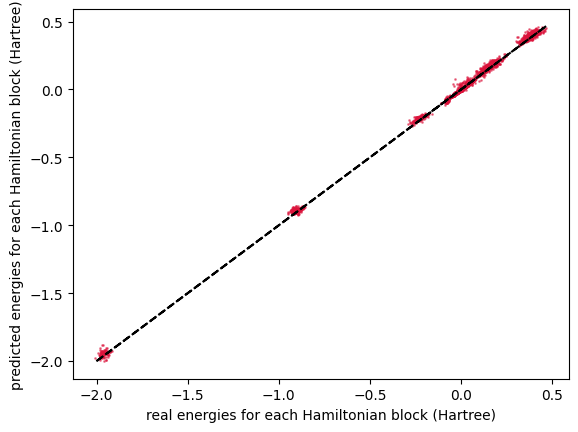

In [ ]:
# node_pred_values = np.concatenate([batch_edge.detach().cpu().numpy().flatten() for batch_edge in node_training])
# node_label_values = np.concatenate([batch_edge.detach().cpu().numpy().flatten() for batch_edge in node_training_labels])

plt.scatter(node_label_tensor.detach().numpy(), node_pred_tensor.detach().numpy(), s=1, alpha=0.5, color = 'crimson')
plt.plot(node_label_tensor, node_label_tensor, c='k',linestyle='dashed')

plt.xlabel("real energies for each Hamiltonian block (Hartree)")
plt.ylabel("predicted energies for each Hamiltonian block (Hartree)")

In [ ]:
edge_label = unflatten(training_labels,numbers, test_batch.edge_index[:,0:test_batch.labelled_edge_size],equivariant_blocks,atom_orbitals,out_slices)
edge_pred = unflatten(training,numbers, test_batch.edge_index[:,0:test_batch.labelled_edge_size],equivariant_blocks,atom_orbitals,out_slices)

In [ ]:
print(edge_label.keys())

dict_keys([(0, 45), (0, 21), (0, 190), (0, 136), (0, 96), (0, 221), (0, 23), (0, 166), (0, 14), (0, 204), (0, 76), (0, 130), (0, 196), (0, 65), (0, 167), (0, 63), (0, 195), (0, 27), (0, 143), (0, 128), (0, 9), (0, 16), (0, 24), (0, 159), (0, 43), (0, 77), (0, 211), (0, 82), (0, 73), (0, 154), (0, 69), (0, 141), (0, 25), (0, 210), (0, 133), (0, 217), (0, 131), (0, 53), (0, 91), (0, 109), (0, 11), (0, 31), (0, 37), (0, 47), (0, 48), (0, 58), (0, 66), (0, 83), (0, 99), (0, 102), (0, 114), (0, 122), (0, 127), (0, 146), (0, 155), (0, 171), (0, 184), (0, 185), (0, 186), (1, 62), (1, 33), (1, 56), (1, 35), (1, 132), (1, 93), (1, 165), (1, 156), (1, 169), (1, 180), (1, 223), (1, 185), (1, 38), (1, 3), (1, 83), (1, 66), (1, 178), (1, 94), (1, 67), (1, 119), (1, 184), (1, 207), (1, 18), (1, 4), (1, 74), (1, 183), (1, 34), (1, 32), (1, 42), (1, 110), (1, 168), (1, 201), (1, 80), (1, 123), (1, 219), (1, 7), (1, 115), (1, 78), (1, 127), (1, 58), (1, 48), (1, 155), (1, 114), (1, 11), (1, 171), (1, 1

In [ ]:
print(edge_label[(0,34)])
print(edge_pred[(0,34)])

edge_errors = []
for key in edge_label.keys():
    edge_error = torch.mean(abs(torch.abs(edge_label[key]-edge_pred[key])))
    edge_errors.append(edge_error.item())

print(np.mean(np.array(edge_errors)))
print(np.max(np.array(edge_errors)))
print(np.min(np.array(edge_errors)))

print(training_labels[1])


KeyError: (0, 34)

In [ ]:
flattened_matrices = [matrix.flatten() for matrix in edge_label.values()]
# Step 2: Concatenate all flattened matrices into a single tensor
edge_label_tensor = torch.cat(flattened_matrices)


flattened_matrices = [matrix.flatten() for matrix in edge_pred.values()]
# Step 2: Concatenate all flattened matrices into a single tensor
edge_pred_tensor = torch.cat(flattened_matrices)




error = abs(edge_label_tensor-edge_pred_tensor)
mean_error = torch.mean(error)

print(mean_error)
print(torch.max(error))
print(torch.min(error))

tensor(0.0002, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor(0.0118, dtype=torch.float64, grad_fn=<MaxBackward1>)
tensor(1.8190e-12, dtype=torch.float64, grad_fn=<MinBackward1>)
